In [1]:
import biom
import pandas as pd
import numpy as np
import biom_to_csv as btc
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#load dataframe
#XSB_90bp    = btc.biom_to_csv_phylum('biom_data/emp_deblur_90bp.release1.biom')
#XSB_cr_13_8 = btc.biom_to_csv_phylum('biom_data/emp_cr_gg_13_8.release1.biom')
#XSB_silva   = btc.biom_to_csv_phylum('biom_data/emp_cr_silva_16S_123.release1.biom')
#XSB_100bp   = btc.biom_to_csv_phylum('biom_data/emp_deblur_100bp.release1.biom')
XSB_150bp   = btc.biom_to_csv_phylum('biom_data/emp_deblur_150bp.release1.biom')
#XSB_2k      = btc.biom_to_csv_phylum('biom_data/emp_2k_90bp.biom')
#XSB_gg_13_8 = btc.biom_to_csv_phylum('biom_data/emp_or_gg_13_8.no_sample_singletons.biom') #dataset molto grande

In [7]:
#calculate bare entropies
Hp, Hs = btc.entropy(XSB_150bp)
print('Entropia phyla')
print(np.sort(Hp)[::-1][:10])
print('Entropia sample')
print(np.sort(Hs)[::-1][:10])

Entropia phyla
[9.07089148 8.9969292  8.59936443 8.34283988 8.24883972 8.16845881
 8.10445524 7.93479778 7.8985285  7.89479653]
Entropia sample
[2.69503494 2.63270793 2.62208333 2.6020303  2.59733812 2.59570434
 2.55318157 2.53635742 2.53344831 2.5293221 ]


In [4]:
#aligne meta data to dataset
meta = pd.read_csv('biom_data/emp_qiime_mapping_release1.tsv', sep='\t', index_col=0, low_memory=False)
meta_filtered = meta.loc[meta.index.isin(XSB_150bp.index)]
meta_aligned = meta_filtered.reindex(XSB_150bp.index)
#meta_aligned.columns

# Studio Temperatura

In [5]:
meta_aligned['temperature_deg_c'].describe()

count    6531.000000
mean       13.260240
std         6.944605
min       -15.000000
25%         8.100000
50%        13.700000
75%        18.000000
max        91.000000
Name: temperature_deg_c, dtype: float64

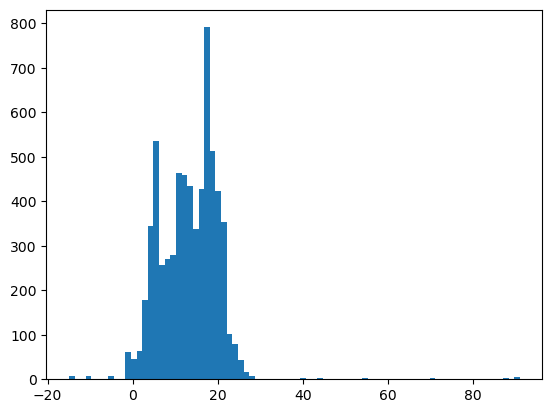

In [6]:
plt.hist(meta_aligned['temperature_deg_c'], bins = 80)
plt.show()

# Studio Ph

In [7]:
meta_aligned['ph'].describe()

count    3344.000000
mean        7.337493
std         1.327752
min         2.100000
25%         6.820000
50%         7.500000
75%         8.080000
max        12.630000
Name: ph, dtype: float64

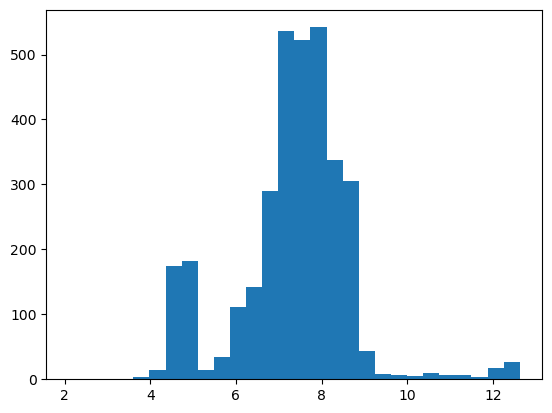

In [8]:
plt.hist(meta_aligned['ph'], bins = 28)
plt.show()

# Correlazione Ph Temperatura

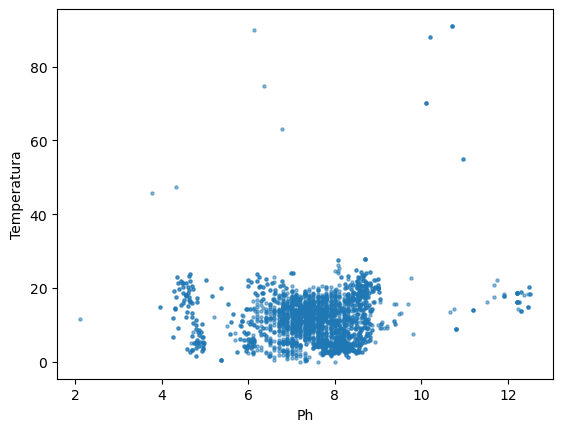

In [9]:
plt.scatter(meta_aligned['ph'], meta_aligned['temperature_deg_c'], alpha = 0.5, s=5)
plt.xlabel('Ph')
plt.ylabel('Temperatura')
plt.show()

In [10]:
df_3d = pd.DataFrame({
    'entropia':    Hs,
    'temperatura': meta_aligned['temperature_deg_c'],
    'ph':          meta_aligned['ph']
}).dropna()

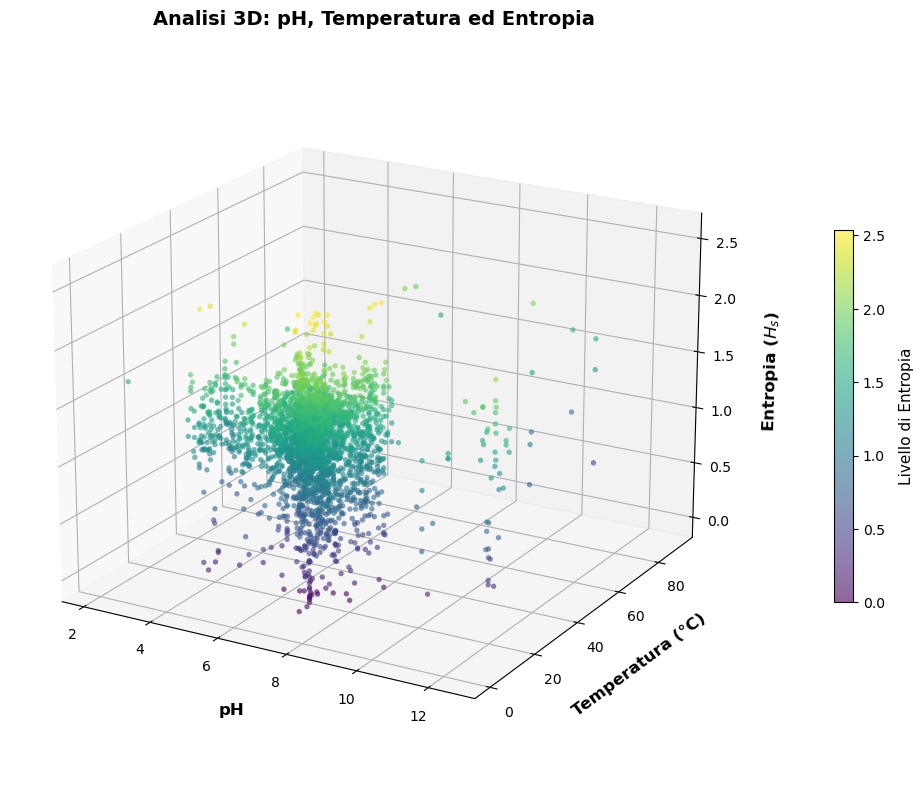

In [11]:
fig = plt.figure(figsize=(10, 8), dpi=100)
ax = plt.axes(projection='3d')

scatter = ax.scatter(
    df_3d['ph'], 
    df_3d['temperatura'], 
    df_3d['entropia'], 
    c=df_3d['entropia'],  
    cmap='viridis',       
    s=15,                 
    alpha=0.6,            
    edgecolors='none'     
)

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Livello di Entropia', fontsize=11, labelpad=10)

ax.set_xlabel('pH', fontsize=12, labelpad=12, fontweight='bold')
ax.set_ylabel('Temperatura (°C)', fontsize=12, labelpad=12, fontweight='bold')
ax.set_zlabel('Entropia ($H_s$)', fontsize=12, labelpad=12, fontweight='bold')

ax.set_title('Analisi 3D: pH, Temperatura ed Entropia', fontsize=14, pad=20, fontweight='bold')

ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()

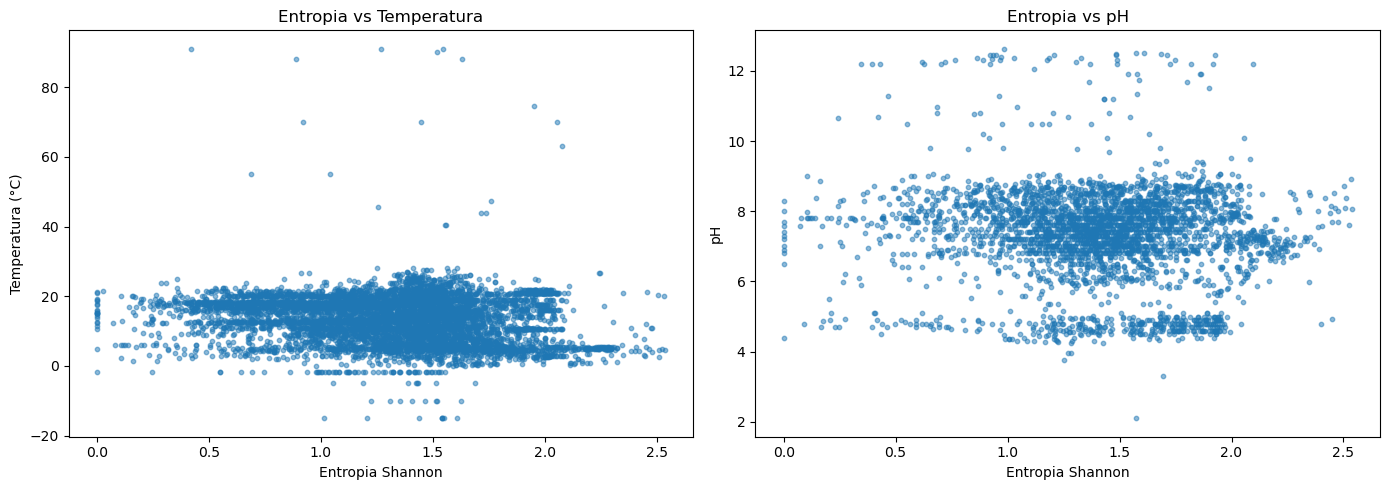

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_temp = pd.DataFrame({
    'entropia': Hs,
    'temperatura': meta_aligned['temperature_deg_c']
}).dropna()

axes[0].scatter(df_temp['entropia'], df_temp['temperatura'], alpha=0.5, s=10)
axes[0].set_xlabel('Entropia Shannon')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Entropia vs Temperatura')

df_ph = pd.DataFrame({
    'entropia': Hs,
    'ph': meta_aligned['ph']
}).dropna()

axes[1].scatter(df_ph['entropia'], df_ph['ph'], alpha=0.5, s=10)
axes[1].set_xlabel('Entropia Shannon')
axes[1].set_ylabel('pH')
axes[1].set_title('Entropia vs pH')

plt.tight_layout()
#plt.savefig('entropia_temp_ph.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlazioni con ubiquità dei phyla

In [13]:
temp = pd.to_numeric(meta_aligned['temperature_deg_c'], errors='coerce')
ph = pd.to_numeric(meta_aligned['ph'], errors='coerce')

risultati = []

for phylum in XSB_150bp.columns:
    
    abundances = XSB_150bp[phylum]
    
    mask_presente = abundances > 0
    n_campioni = mask_presente.sum()
    
    mask_temp = mask_presente & temp.notna()
    if mask_temp.sum() > 0:
        w = abundances[mask_temp]
        T_pesata = np.average(temp[mask_temp], weights=w)
    else:
        T_pesata = np.nan
    
    mask_ph = mask_presente & ph.notna()
    if mask_ph.sum() > 0:
        w = abundances[mask_ph]
        pH_pesato = np.average(ph[mask_ph], weights=w)
    else:
        pH_pesato = np.nan
    
    risultati.append({
        'phylum': phylum,
        'n_campioni': n_campioni,
        'T_media_pesata': T_pesata,
        'pH_medio_pesato': pH_pesato,
        'H_phylum': Hp[phylum]
    })

df_phyla = pd.DataFrame(risultati).set_index('phylum')
print(df_phyla.shape)
print(df_phyla.sort_values('n_campioni', ascending=False).head(10))

(81, 4)
                    n_campioni  T_media_pesata  pH_medio_pesato  H_phylum
phylum                                                                   
p__Proteobacteria        17411       13.416689         7.295930  9.070891
p__Bacteroidetes         16958       12.051448         7.538178  8.996929
p__Actinobacteria        16166       12.422721         7.300120  8.599364
p__Cyanobacteria         14180       11.819430         7.532281  7.571775
p__Firmicutes            14004       13.184294         7.656283  8.248840
p__Verrucomicrobia       13761       11.914334         7.026970  8.168459
p__Unknown               11789       11.404281         6.822765  8.104455
p__Planctomycetes        10914       13.563306         7.748679  8.342840
p__Acidobacteria          9195       14.273728         6.758824  7.898528
p__Chloroflexi            8128        9.464054         7.723652  7.894797


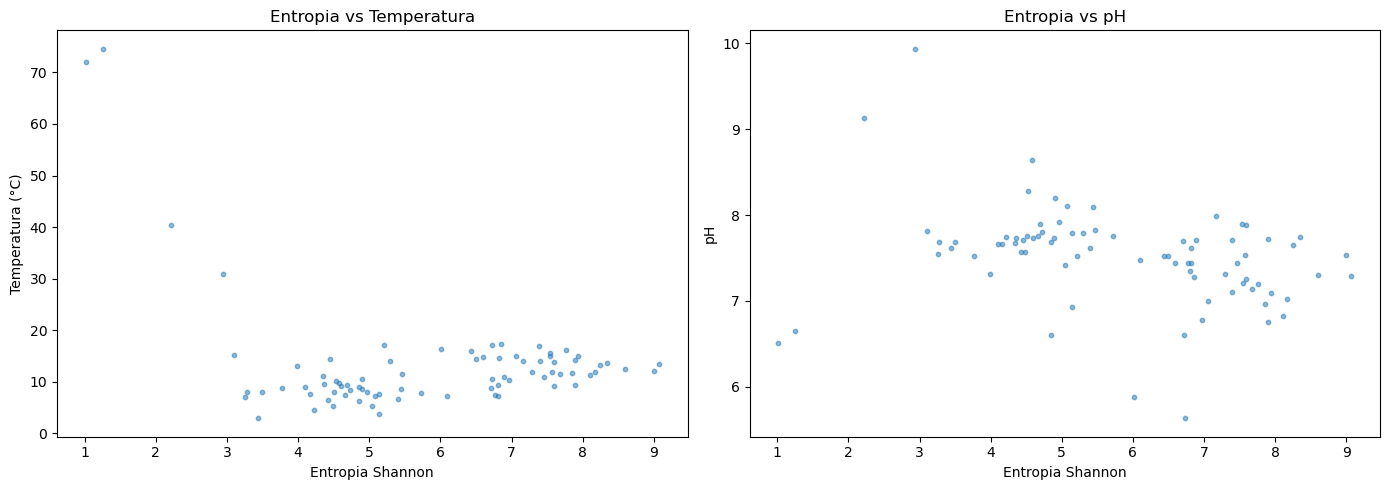

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_phyla['H_phylum'], df_phyla['T_media_pesata'], alpha=0.5, s=10)
axes[0].set_xlabel('Entropia Shannon')
axes[0].set_ylabel('Temperatura (°C)')
axes[0].set_title('Entropia vs Temperatura')

axes[1].scatter(df_phyla['H_phylum'], df_phyla['pH_medio_pesato'], alpha=0.5, s=10)
axes[1].set_xlabel('Entropia Shannon')
axes[1].set_ylabel('pH')
axes[1].set_title('Entropia vs pH')

plt.tight_layout()
#plt.savefig('entropia_temp_ph.png', dpi=150, bbox_inches='tight')
plt.show()

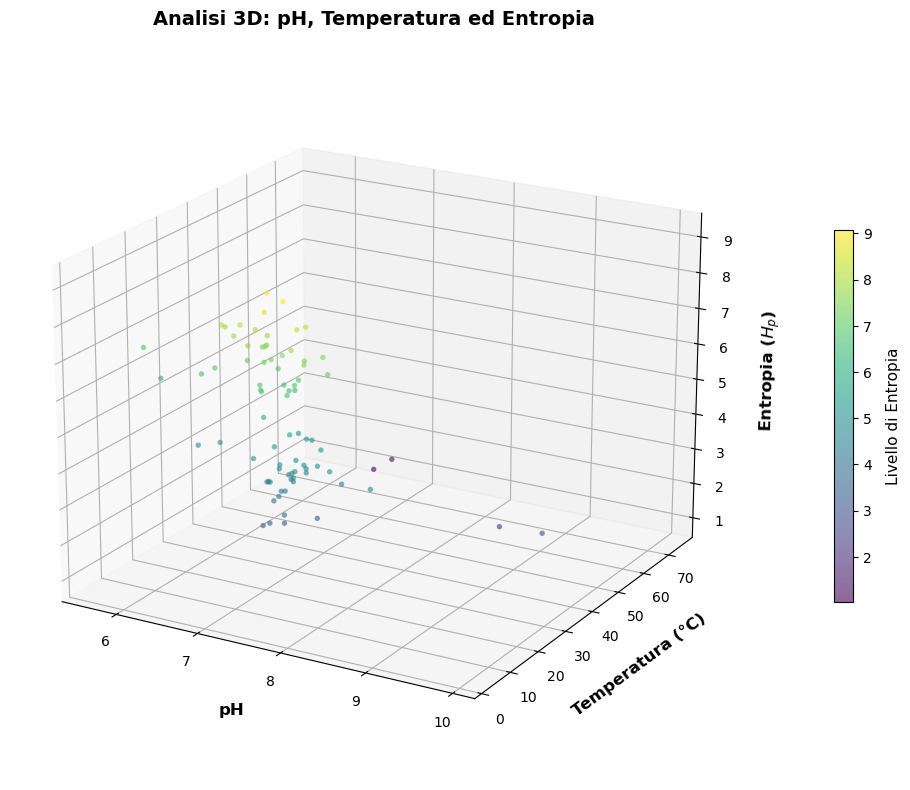

In [15]:
fig = plt.figure(figsize=(10, 8), dpi=100)
ax = plt.axes(projection='3d')

scatter = ax.scatter(
    df_phyla['pH_medio_pesato'], 
    df_phyla['T_media_pesata'], 
    df_phyla['H_phylum'], 
    c=df_phyla['H_phylum'],  
    cmap='viridis',       
    s=15,                 
    alpha=0.6,            
    edgecolors='none'     
)

cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
cbar.set_label('Livello di Entropia', fontsize=11, labelpad=10)

ax.set_xlabel('pH', fontsize=12, labelpad=12, fontweight='bold')
ax.set_ylabel('Temperatura (°C)', fontsize=12, labelpad=12, fontweight='bold')
ax.set_zlabel('Entropia ($H_p$)', fontsize=12, labelpad=12, fontweight='bold')

ax.set_title('Analisi 3D: pH, Temperatura ed Entropia', fontsize=14, pad=20, fontweight='bold')

ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()

In [16]:
#subdivide dataset in groups
gruppi = {}
for gruppo in meta_aligned['empo_2'].unique():
    mask = meta_aligned['empo_2'] == gruppo
    gruppi[gruppo] = XSB_150bp[mask]
    print(f"{gruppo}: {gruppi[gruppo].shape}")
gruppi.pop("Negative")
#gruppi.pop("Positive")

Plant: (1818, 81)
Non-saline: (8625, 81)
Animal: (6085, 81)
Saline: (953, 81)
Negative: (2, 81)


,p__Proteobacteria,p__Cyanobacteria,p__Bacteroidetes,p__TM6,p__Firmicutes,p__Chloroflexi,p__Unknown,p__Armatimonadetes,p__Gemmatimonadetes,p__OP3,...,p__OP1,p__TPD-58,p__AncK6,p__H-178,p__Caldiserica,p__OC31,p__Aquificae,p__OctSpA1-106,p__VHS-B3-43,p__Thermotogae
1883.empty.well.2.Crump.Artic.LTREB.main.lane4.NoIndex,3.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1883.vacant.Crump.Artic.LTREB.main.lane1.NoIndex,159.0,0.0,36.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Studio per gruppo

In [17]:
#calculate bare entropies for each group
entropie = {}

for gruppo, matrice in gruppi.items():
    Hp, Hs = btc.entropy(matrice)
    entropie[gruppo] = {'Hp': Hp, 'Hs': Hs}

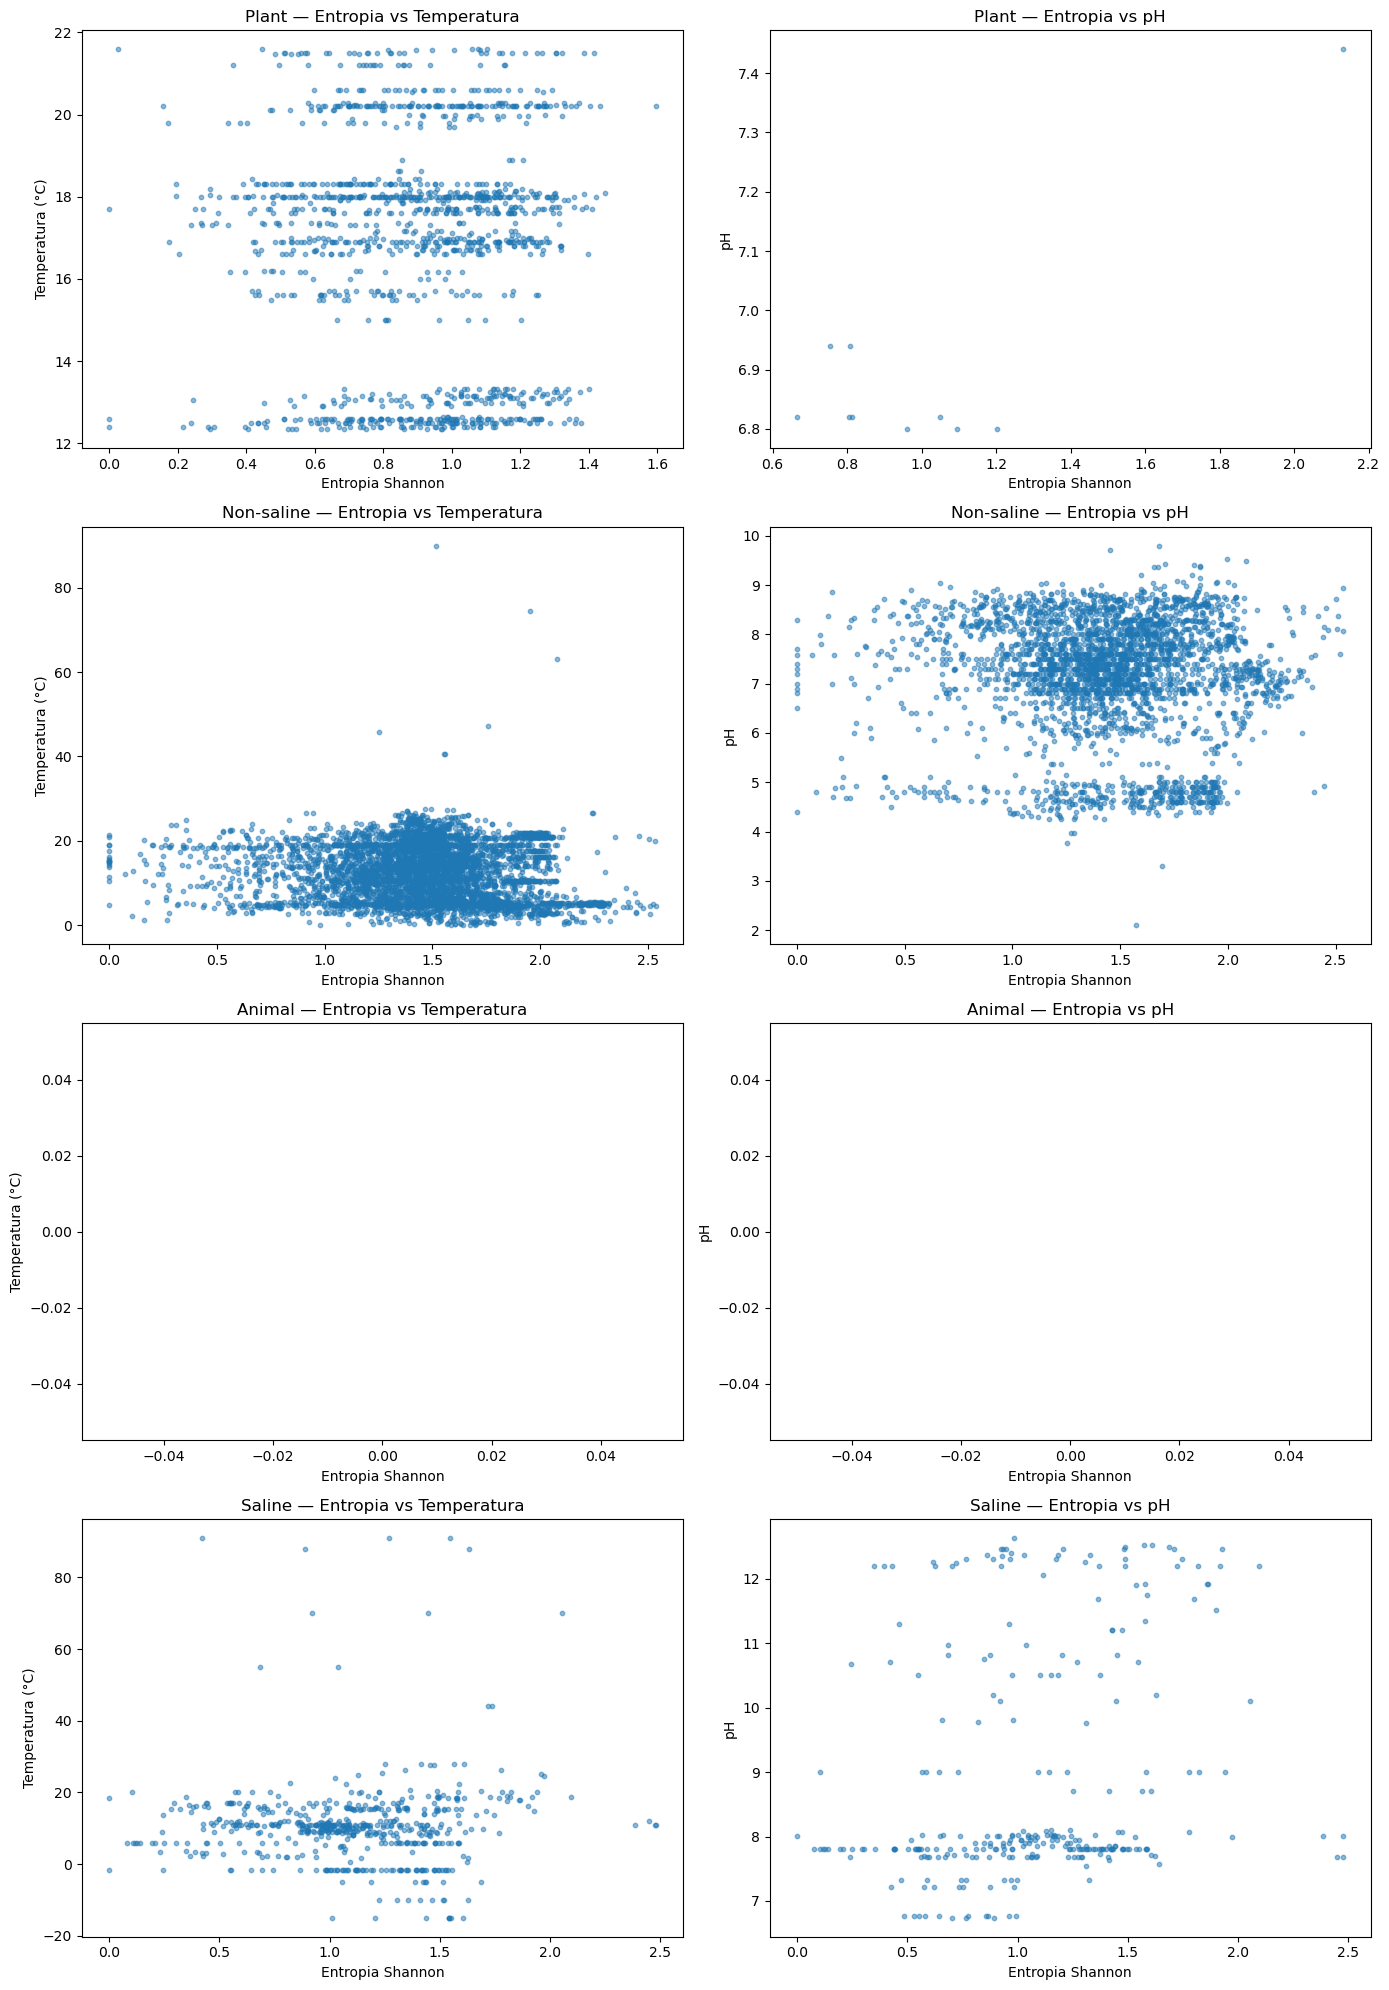

In [18]:
gruppi_nomi = list(gruppi.keys())
fig, axes = plt.subplots(len(gruppi_nomi), 2, figsize=(14, 5 * len(gruppi_nomi)))

for i, gruppo in enumerate(gruppi_nomi):
    Hs = entropie[gruppo]['Hs']
    
    df_temp = pd.DataFrame({
        'entropia': Hs,
        'temperatura': meta_aligned.loc[gruppi[gruppo].index, 'temperature_deg_c']
    }).dropna()
    
    axes[i, 0].scatter(df_temp['entropia'], df_temp['temperatura'], alpha=0.5, s=10)
    axes[i, 0].set_xlabel('Entropia Shannon')
    axes[i, 0].set_ylabel('Temperatura (°C)')
    axes[i, 0].set_title(f'{gruppo} — Entropia vs Temperatura')
    
    df_ph = pd.DataFrame({
        'entropia': Hs,
        'ph': meta_aligned.loc[gruppi[gruppo].index, 'ph']
    }).dropna()
    
    axes[i, 1].scatter(df_ph['entropia'], df_ph['ph'], alpha=0.5, s=10)
    axes[i, 1].set_xlabel('Entropia Shannon')
    axes[i, 1].set_ylabel('pH')
    axes[i, 1].set_title(f'{gruppo} — Entropia vs pH')

plt.tight_layout()
# plt.savefig('entropia_temp_ph_gruppi.png', dpi=150, bbox_inches='tight')
plt.show()

# Nestedness

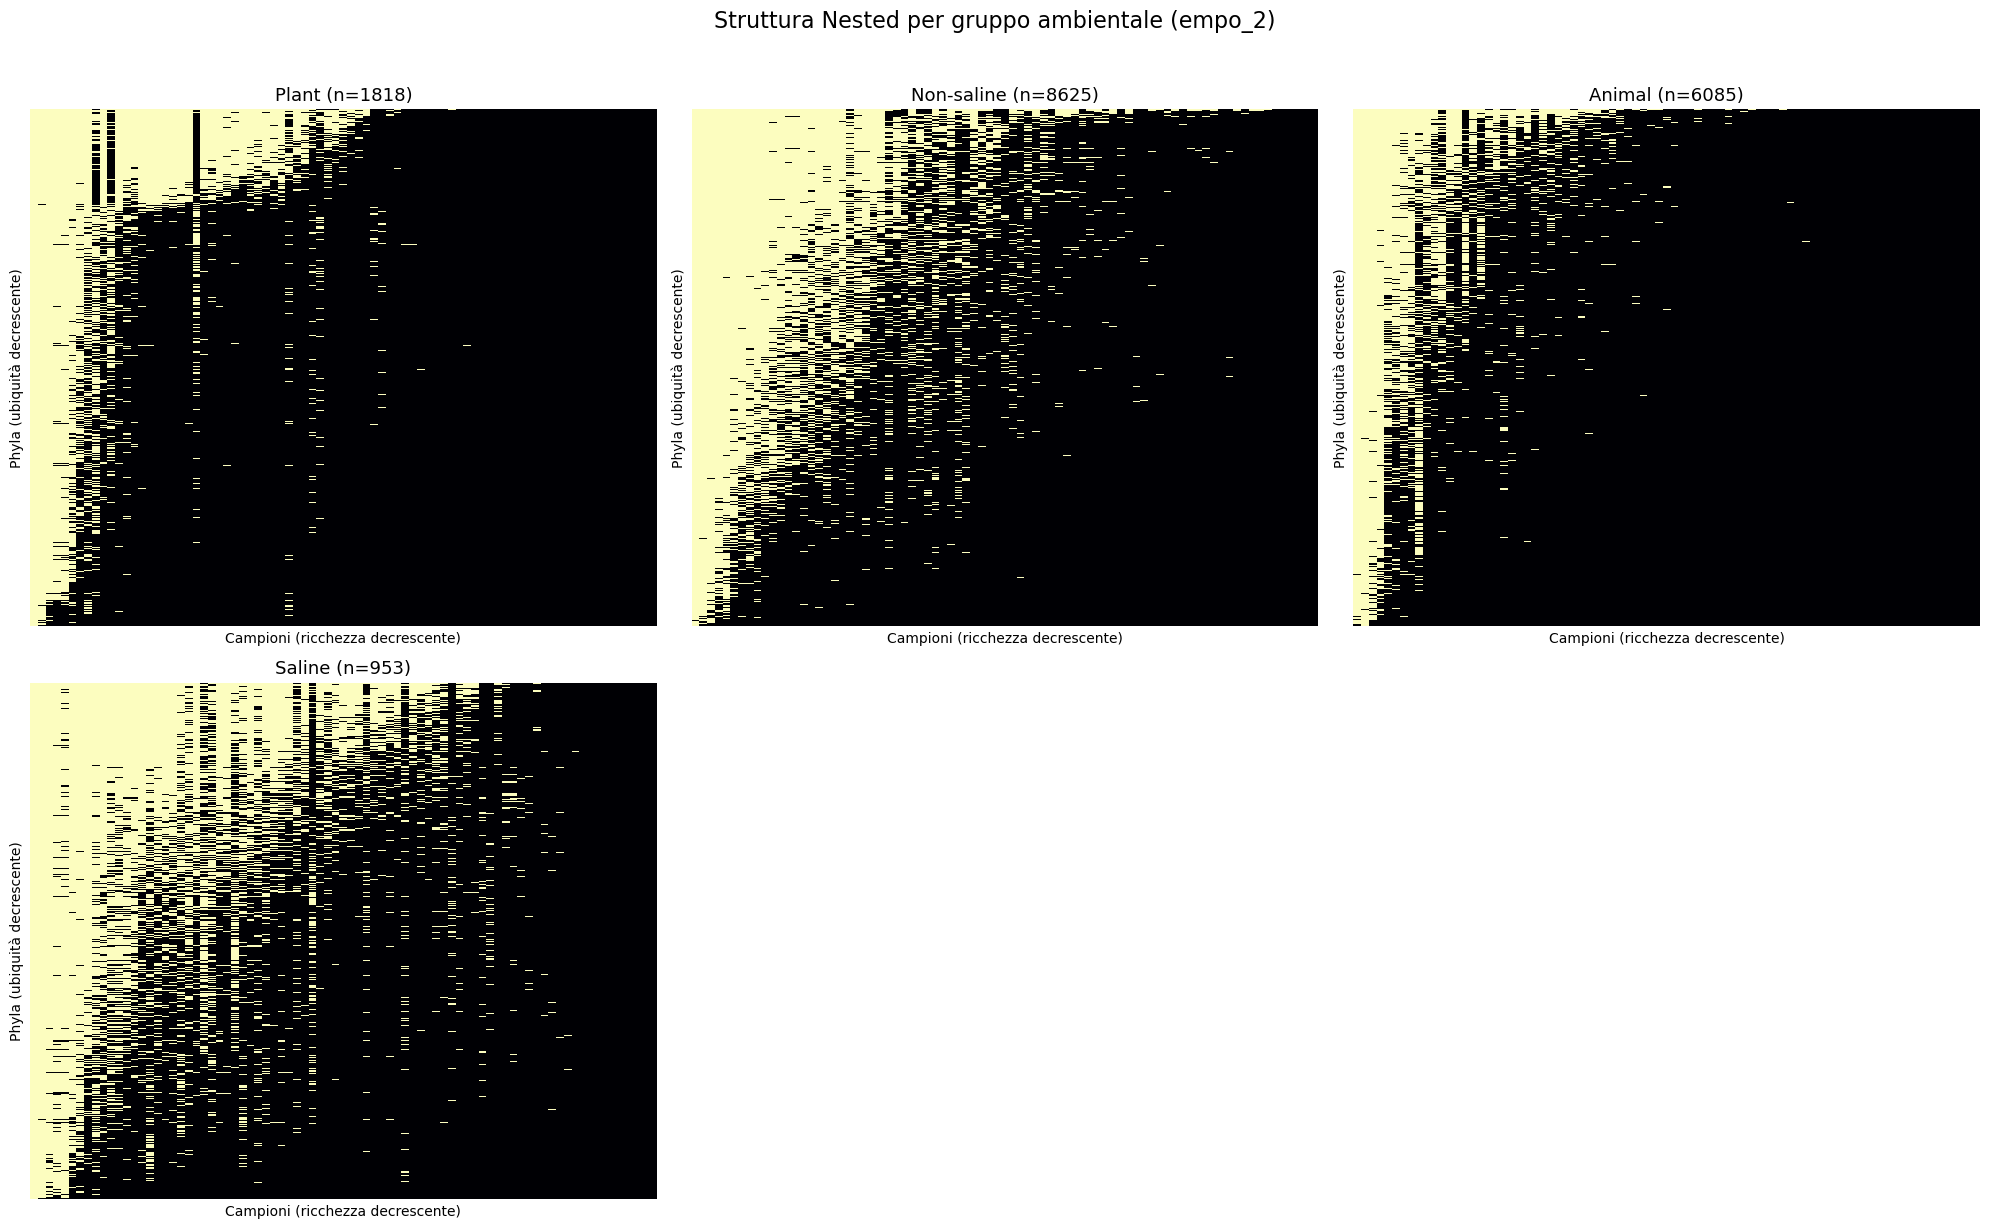

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for idx, (gruppo, df) in enumerate(gruppi.items()):

    df_bin = (df > 0).astype(int)
    
    phyla_sum = df_bin.sum(axis=1)
    samples_sum = df_bin.sum(axis=0)
    
    df_sorted = df_bin.loc[
        phyla_sum.sort_values(ascending=False).index,
        samples_sum.sort_values(ascending=False).index
    ]
    
    sns.heatmap(df_sorted,
                cmap='magma',
                cbar=False,
                xticklabels=False,
                yticklabels=False,
                ax=axes[idx])
    
    axes[idx].set_title(f'{gruppo} (n={df.shape[0]})', fontsize=13)
    axes[idx].set_xlabel('Campioni (ricchezza decrescente)')
    axes[idx].set_ylabel('Phyla (ubiquità decrescente)')

for idx in range(len(gruppi), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Struttura Nested per gruppo ambientale (empo_2)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()